# EDA: Global AI Workforce Automation (2015-2025)

Exploratory Data Analysis of global AI workforce automation trends.

## Tasks:
- Load and inspect workforce data
- Analyze trends over time
- Regional/sectoral analysis
- Automation impact patterns


In [1]:
# Imports & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
df_workforce = pd.read_csv('../data/global_ai_workforce_automation_2015_2025.csv')

print("="*60)
print("DATASET SHAPE & INFO")
print("="*60)
print(f"Shape: {df_workforce.shape}")
print(f"\nFirst 5 rows:")
print(df_workforce.head())
print(f"\nData Types:")
print(df_workforce.dtypes)
print(f"\nMissing Values:")
print(df_workforce.isnull().sum())

DATASET SHAPE & INFO
Shape: (220, 12)

First 5 rows:
   Year        Country  AI_Investment_BillionUSD  Automation_Rate_Percent  \
0  2015  United States                     52.46                    10.75   
1  2016  United States                     60.64                    11.64   
2  2017  United States                     66.11                    12.46   
3  2018  United States                     72.45                    13.35   
4  2019  United States                     79.11                    14.65   

   Employment_Rate_Percent  Average_Salary_USD  Productivity_Index  \
0                    65.50            38392.64               65.78   
1                    65.25            39371.74               67.02   
2                    64.93            40772.29               68.51   
3                    64.84            43974.92               71.09   
4                    64.55            43745.39               69.89   

   Reskilling_Investment_MillionUSD  AI_Policy_Index  \
0      

In [2]:
# Summary Statistics

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(df_workforce.describe())


SUMMARY STATISTICS
              Year  AI_Investment_BillionUSD  Automation_Rate_Percent  \
count   220.000000                220.000000               220.000000   
mean   2020.000000                 82.364409                27.352136   
std       3.169489                 42.522535                 8.860064   
min    2015.000000                  5.400000                10.190000   
25%    2017.000000                 47.642500                20.337500   
50%    2020.000000                 81.375000                27.085000   
75%    2023.000000                114.480000                33.812500   
max    2025.000000                177.290000                48.410000   

       Employment_Rate_Percent  Average_Salary_USD  Productivity_Index  \
count               220.000000          220.000000           220.00000   
mean                 68.818909        62074.483818            60.61450   
std                   5.833969        19472.117474            11.09393   
min                  57.12

In [3]:
# Categorical Analysis

print("\n" + "="*60)
print("CATEGORICAL COLUMNS ANALYSIS")
print("="*60)

categorical_cols = df_workforce.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df_workforce[col].nunique()}")
    print(df_workforce[col].value_counts().head(10))


CATEGORICAL COLUMNS ANALYSIS

Country:
  Unique values: 20
Country
United States    11
China            11
South Africa     11
Italy            11
Spain            11
Singapore        11
Turkey           11
Sweden           11
Netherlands      11
Russia           11
Name: count, dtype: int64


## Time Series & Distribution Analysis

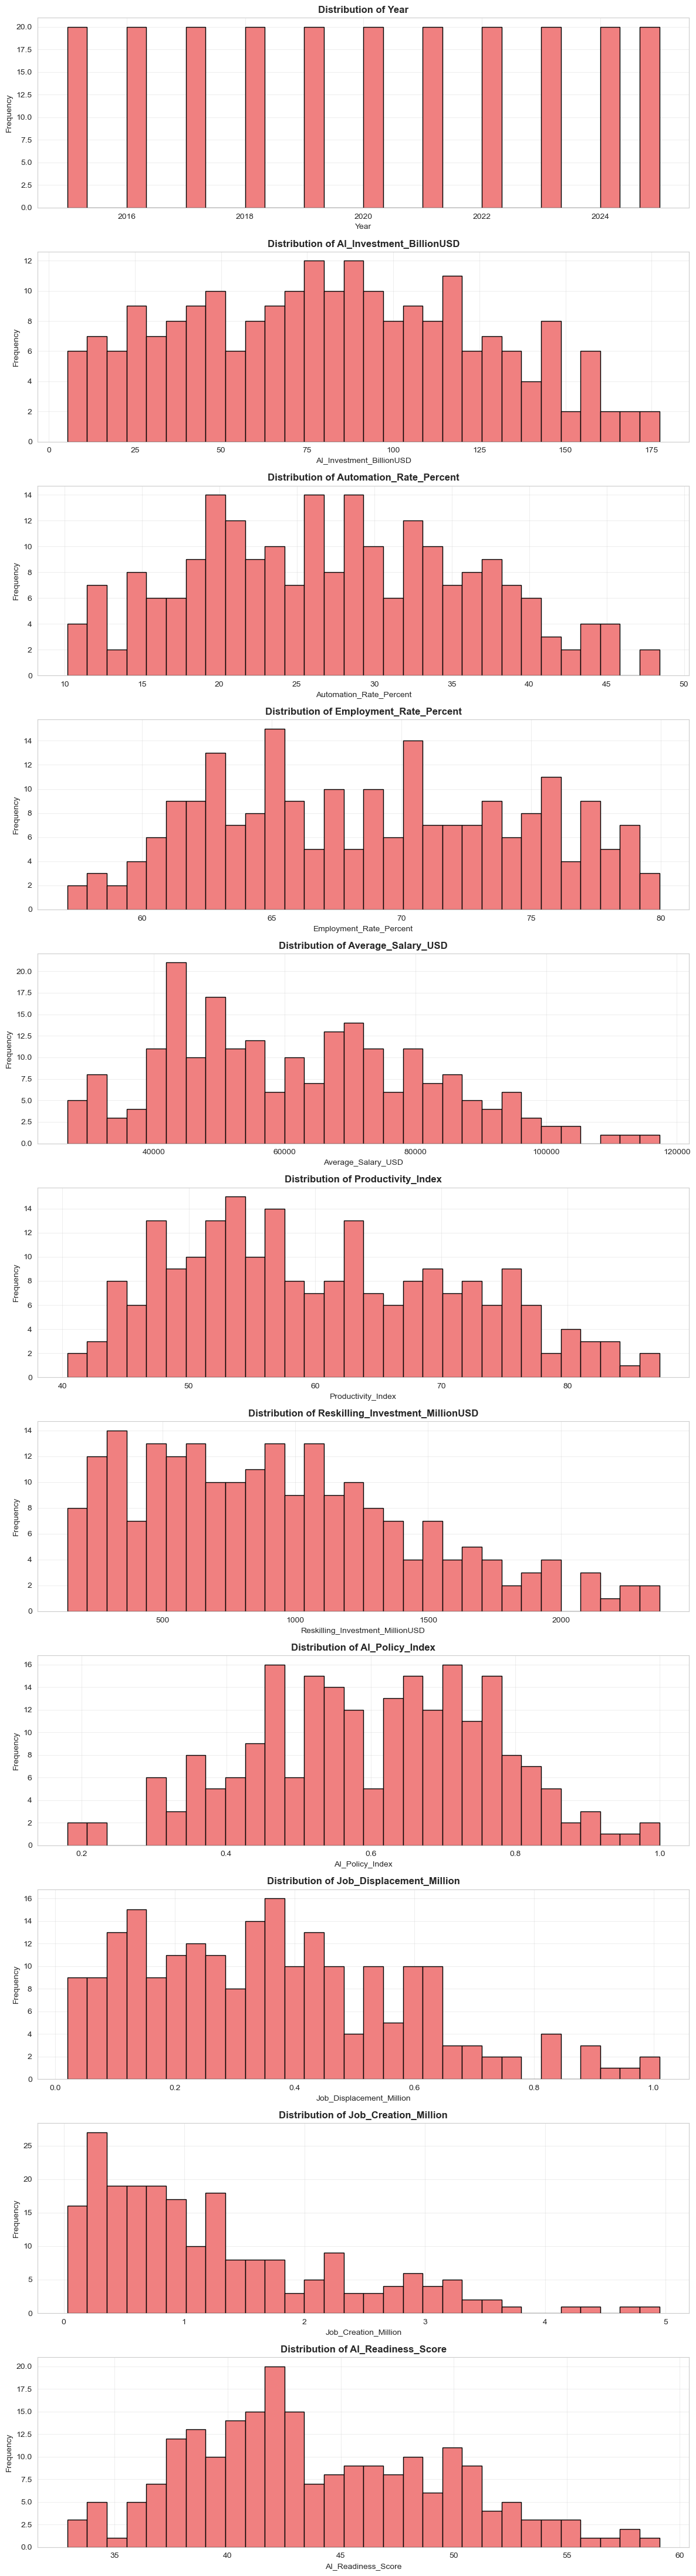

In [4]:
# Numeric Distributions

numeric_cols = df_workforce.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4*len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    df_workforce[col].hist(bins=30, ax=ax, edgecolor='black', color='lightcoral')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation Matrix:
                                      Year  AI_Investment_BillionUSD  \
Year                              1.000000                  0.461813   
AI_Investment_BillionUSD          0.461813                  1.000000   
Automation_Rate_Percent           0.357450                  0.339841   
Employment_Rate_Percent          -0.190949                 -0.114541   
Average_Salary_USD                0.304879                  0.378171   
Productivity_Index                0.379031                  0.525494   
Reskilling_Investment_MillionUSD  0.488412                  0.178607   
AI_Policy_Index                  -0.127808                 -0.138892   
Job_Displacement_Million          0.151502                  0.169902   
Job_Creation_Million              0.332982                  0.652887   
AI_Readiness_Score                0.280716                  0.319543   

                                  Automation_Rate_Percent  \
Year                                             0.357

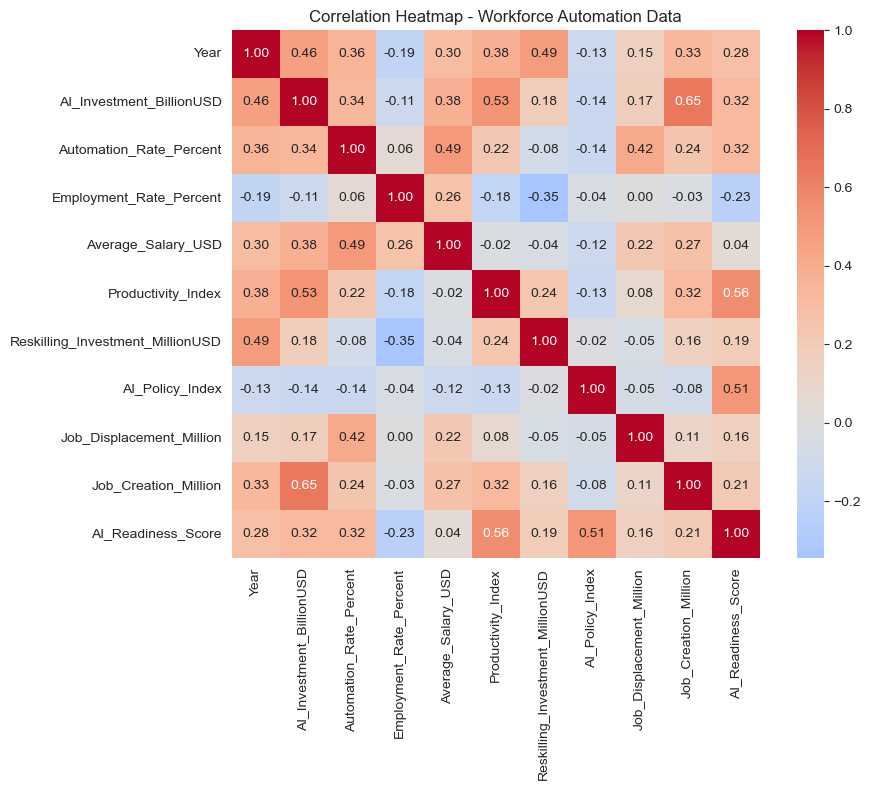

In [5]:
# Correlation Heatmap

numeric_cols = df_workforce.select_dtypes(include=[np.number]).columns
corr_matrix = df_workforce[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap - Workforce Automation Data')
plt.tight_layout()
plt.show()